In [20]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# 1. Инициализация ГПСЧ для X ~ U[0, 1]

Инициализируем генератор `rng`, используя конструктор `default_rng` из библиотеки `numpy`.

In [2]:
rng = np.random.default_rng()

# 2. Нахождение зависимости между мат.ожиданием, дисперсией и размером выборки

In [ ]:
sample_sizes = [10 ** n for n in range(2, 9)]
sample_means = []
sample_vars = []

progress_bar = tqdm(sample_sizes, desc=f"Compute mean and var for sample sizes {sample_sizes}")
for sample_size in progress_bar:
    sample = rng.uniform(0., 1., size=sample_size)
    sample_mean = np.mean(sample)
    sample_var = np.var(sample)

    sample_means.append(sample_mean)
    sample_vars.append(sample_var)

Compute mean and var for sample sizes [100, 1000, 10000, 100000, 1000000, 10000000, 100000000]: 100%|██████████| 7/7 [00:01<00:00,  3.81it/s]


Построим график зависимости математического ожидания `mean` от размера выборки $N$.

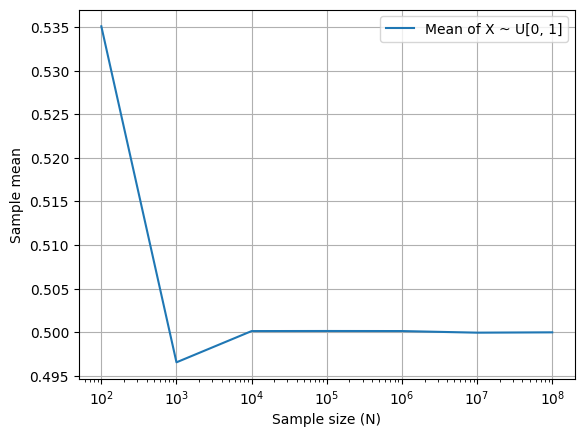

In [4]:
plt.plot(sample_sizes, sample_means, label='Mean of X ~ U[0, 1]')
plt.xlabel('Sample size (N)')
plt.ylabel('Sample mean')
plt.xscale('log')
plt.legend()
plt.grid()

Построим график зависимости дисперсии `var` от размера выборки $N$.

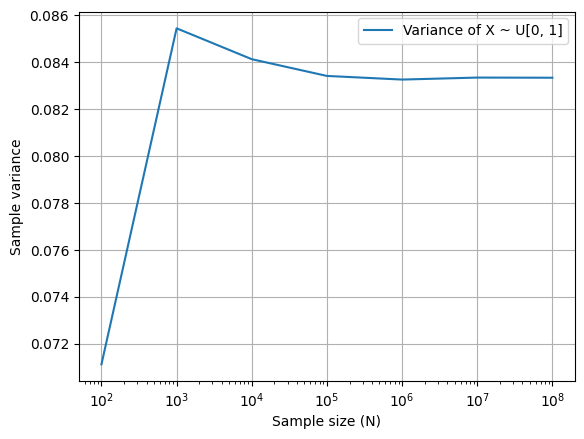

In [5]:
plt.plot(sample_sizes, sample_vars, label='Variance of X ~ U[0, 1]')
plt.xlabel('Sample size (N)')
plt.ylabel('Sample variance')
plt.xscale('log')
plt.legend()
plt.grid()

# 3. Построение гистограммы и вычисление погрешности (расхождение сгенерированных чисел с теоретическим значением)

In [ ]:
sample_size = 10 ** 8
sample = rng.uniform(0., 1., size=sample_size)

num_bins = 32
sample_hist, bin_edges = np.histogram(sample, bins=num_bins, density=True)

Построим приближенную гистограмму равномерного распределения на основе сгенерированных данных (`sample`).

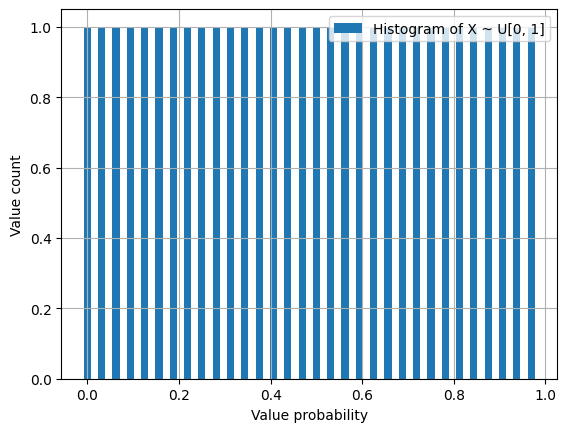

In [ ]:
plt.bar(bin_edges[:-1], sample_hist, width=np.diff(bin_edges) / 2, label='Histogram of X ~ U[0, 1]')
plt.xlabel('Value probability')
plt.ylabel('Value count')
plt.legend()
plt.grid()

In [8]:
def distribution_error(
    p: np.ndarray,
    p_true: float = 1.
):
    return np.sum((p - p_true) ** 2)

In [9]:
sample_sizes = [10 ** n for n in range(2, 9)]
errors = []
hist_true = 1.

progress_bar = tqdm(sample_sizes, desc=f"Compute distribution error for sample sizes {sample_sizes}")
for sample_size in progress_bar:
    sample = rng.uniform(0., 1., size=sample_size)
    hist, _ = np.histogram(sample, bins=num_bins, density=True)
    error = distribution_error(hist, p_true=hist_true)
    errors.append(error)

Compute distribution error for sample sizes [100, 1000, 10000, 100000, 1000000, 10000000, 100000000]: 100%|██████████| 7/7 [00:02<00:00,  2.34it/s]


Построим график зависимости погрешности `distribution_error` от размера выборки $N$.

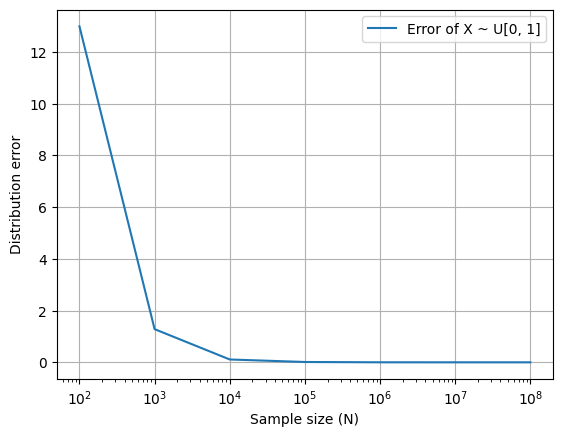

In [10]:
plt.plot(sample_sizes, errors, label='Error of X ~ U[0, 1]')
plt.xlabel('Sample size (N)')
plt.ylabel('Distribution error')
plt.xscale('log')
plt.legend()
plt.grid()

# 4. Вычисление коэффициента корреляции между двумя выборками из одного распределения, но построенными разными способами

In [11]:
def pearson_r(x: np.ndarray, y: np.ndarray):
    return np.sum((x - x.mean()) * (y - y.mean())) / np.sqrt(np.sum((x - x.mean()) ** 2) * np.sum((y - y.mean()) ** 2))

In [16]:
# a)
sample_sizes = [10 ** n for n in range(2, 9)]
corr_coeffs_a = []

progress_bar = tqdm(sample_sizes, desc=f"Compute correlation for sample sizes {sample_sizes}")
for sample_size in progress_bar:
    x = rng.uniform(0., 1., size=sample_size)
    y = rng.uniform(0., 1., size=sample_size)
    r_xy = pearson_r(x, y)
    corr_coeffs_a.append(r_xy)

Compute correlation for sample sizes [100, 1000, 10000, 100000, 1000000, 10000000, 100000000]: 100%|██████████| 7/7 [00:16<00:00,  2.36s/it]


Построим график зависимости коэффициента корреляции `pearson_r` от размера выборки $N$ (вариант *а*).

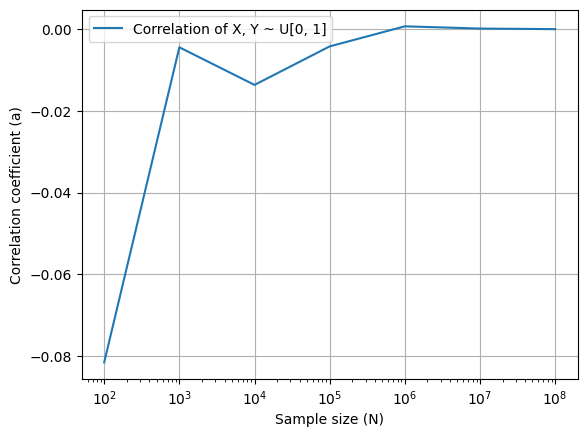

In [17]:
plt.plot(sample_sizes, corr_coeffs_a, label='Correlation of X, Y ~ U[0, 1]')
plt.xlabel('Sample size (N)')
plt.ylabel('Correlation coefficient (a)')
plt.xscale('log')
plt.legend()
plt.grid()

In [18]:
# b)
sample_sizes = [10 ** n for n in range(2, 9)]
corr_coeffs_b = []

progress_bar = tqdm(sample_sizes, desc=f"Compute correlation for sample sizes {sample_sizes}")
for sample_size in progress_bar:
    z = rng.uniform(0., 1., size=2 * sample_size)
    x = z[::2]
    y = z[1::2]
    r_xy = pearson_r(x, y)
    corr_coeffs_b.append(r_xy)

Compute correlation for sample sizes [100, 1000, 10000, 100000, 1000000, 10000000, 100000000]: 100%|██████████| 7/7 [00:04<00:00,  1.48it/s]


Построим график зависимости коэффициента корреляции `pearson_r` от размера выборки $N$ (вариант *б*).

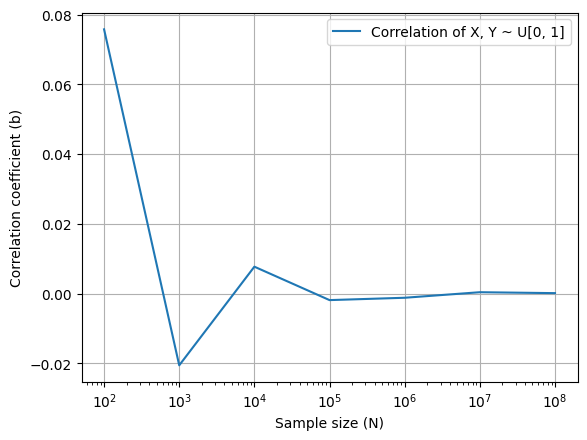

In [19]:
plt.plot(sample_sizes, corr_coeffs_b, label='Correlation of X, Y ~ U[0, 1]')
plt.xlabel('Sample size (N)')
plt.ylabel('Correlation coefficient (b)')
plt.xscale('log')
plt.legend()
plt.grid()